In [1]:
pip install pandas numpy matplotlib seaborn jupyter ipykernel


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 7.3 MB/s eta 0:00:00
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached arrow-1.4.0-py3-none-any.whl.metadata (7.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 46.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Tudo importado com sucesso!")

Tudo importado com sucesso!


In [4]:
mkdir -p ~/.kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/workspaces/Top-Radar/creditcard.csv')

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print(f"\nFraudes: {df['Class'].sum():,}")
print(f"Legítimas: {(df['Class'] == 0).sum():,}")
print(f"\n% de fraude: {df['Class'].mean()*100:.2f}%")

Linhas: 284,807
Colunas: 31

Fraudes: 492
Legítimas: 284,315

% de fraude: 0.17%


/tmp/ipykernel_20417/2121882834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df,


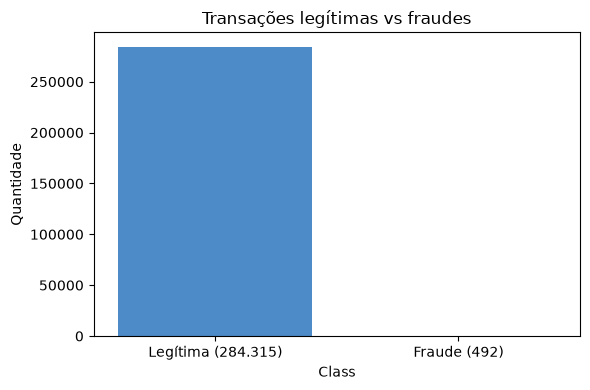

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df,
              palette=['#378ADD', '#E24B4A'])
plt.title('Transações legítimas vs fraudes')
plt.xticks([0, 1], ['Legítima (284.315)', 'Fraude (492)'])
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

Fraudes   — média: $122.21 | máx: $2125.87
Legítimas — média: $88.29 | máx: $25691.16


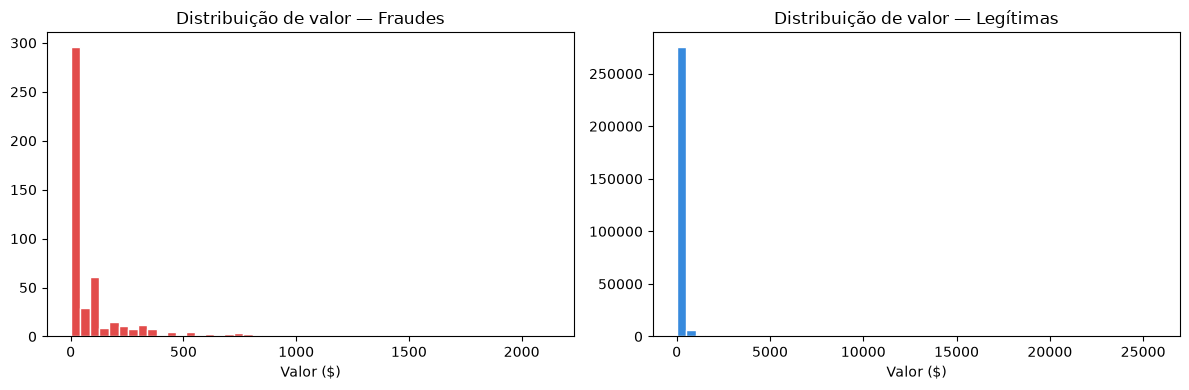

In [3]:
fraudes   = df[df['Class'] == 1]['Amount']
legitimas = df[df['Class'] == 0]['Amount']

print(f"Fraudes   — média: ${fraudes.mean():.2f} | máx: ${fraudes.max():.2f}")
print(f"Legítimas — média: ${legitimas.mean():.2f} | máx: ${legitimas.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fraudes,   bins=50, color='#E24B4A', edgecolor='white')
axes[0].set_title('Distribuição de valor — Fraudes')
axes[0].set_xlabel('Valor ($)')
axes[1].hist(legitimas, bins=50, color='#378ADD', edgecolor='white')
axes[1].set_title('Distribuição de valor — Legítimas')
axes[1].set_xlabel('Valor ($)')
plt.tight_layout()
plt.show()

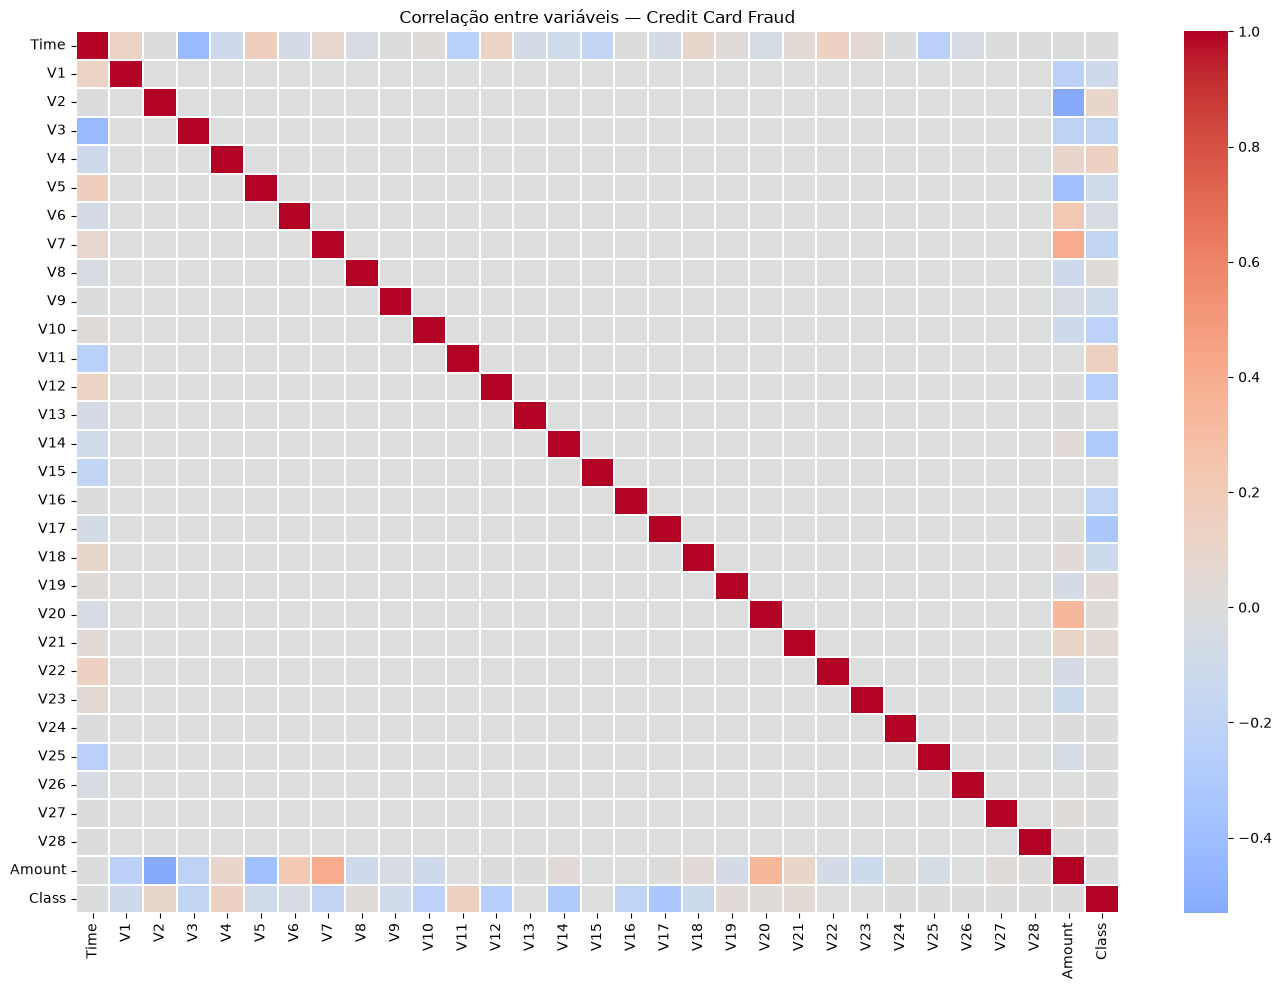


Features mais correlacionadas com fraude:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [4]:
plt.figure(figsize=(14, 10))
corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False
)
plt.title('Correlação entre variáveis — Credit Card Fraud')
plt.tight_layout()
plt.show()

print("\nFeatures mais correlacionadas com fraude:")
print(corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10))